# Gesture Dataset Loading and LSTM Training
This notebook loads gesture datasets from the `custom` and `xml_logs` folders, compares their contents, and trains an LSTM model on the xml_logs dataset.  
This LSTM model is then evaluated with different hyperparameters and compared to the $1 unistroke recognizer.  

## Init

In [ ]:
import os
from collections import Counter, defaultdict
import numpy as np
import xml.etree.ElementTree as ET
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.utils import to_categorical
import matplotlib.pyplot as plt
from recognizer.recognizer import Recognizer
import time

np.random.seed(42)
tf.random.set_seed(42)

# Helper: Parse points from XML file
def parse_gesture_xml(file_path):
    xml_root = ET.parse(file_path).getroot()
    points = []
    for element in xml_root.findall("Point"):
        x = float(element.get("X"))
        y = float(element.get("Y"))
        points.append([x, y])
    return np.array(points, dtype=float), file_path

## 2. Load Custom and xml_logs Datasets
Load gesture data from both the `datasets/custom` and `datasets/xml_logs` directories. Parse XML files and load the data into pandas DataFrames or numpy arrays.

All loaded gestures are normalized in the same way for both recognizer and LSTM that will later be trained and evaluated.

In [2]:
# Paths to datasets
datasets_dir = 'datasets'
custom_dir = os.path.join(datasets_dir, 'custom')
xml_logs_dir = os.path.join(datasets_dir, 'xml_logs')
helper_recognizer = Recognizer()  # Assuming this is defined elsewhere

# Helper: Recursively find all XML files in a directory
def find_xml_files(root_dir):
    return [y for x in os.walk(root_dir) for y in glob(os.path.join(x[0], '*.xml'))]

# Load custom dataset and normalize
custom_files = find_xml_files(custom_dir)
custom_data = []
custom_labels = []
for file in custom_files:
    points, path = parse_gesture_xml(file)
    norm_points, _ = helper_recognizer.normalize(points)
    label = os.path.basename(file).split('.')[0][:-2]
    custom_data.append(norm_points)
    custom_labels.append(label)

# Load xml_logs dataset and normalize
xml_logs_files = find_xml_files(xml_logs_dir)
xml_logs_data = []
xml_logs_labels = []
for file in xml_logs_files:
    points, path = parse_gesture_xml(file)
    norm_points, _ = helper_recognizer.normalize(points)
    label = os.path.basename(file).split('.')[0][:-2]
    xml_logs_data.append(norm_points)
    xml_logs_labels.append(label)

print(f"Loaded {len(custom_data)} samples from custom, {len(xml_logs_data)} from xml_logs.")

Loading gesture templates (Sync): [------------------------------] 15/5280

Loading gesture templates (Sync): [==============================] 5280/5280
Loaded 52 samples from custom, 5280 from xml_logs.


## 3. Limit Dataset Size to Smallest Dataset
To ensure a fair comparison, limit both datasets to the size of the smaller one.  
They have already been normalized, so there are no differences besides the data itself.  
Below this code cell are a few metrics to show that the datasets are loaded correctly with the same dimensions and format.

Symmetrical datasets created with 52 samples per dataset.


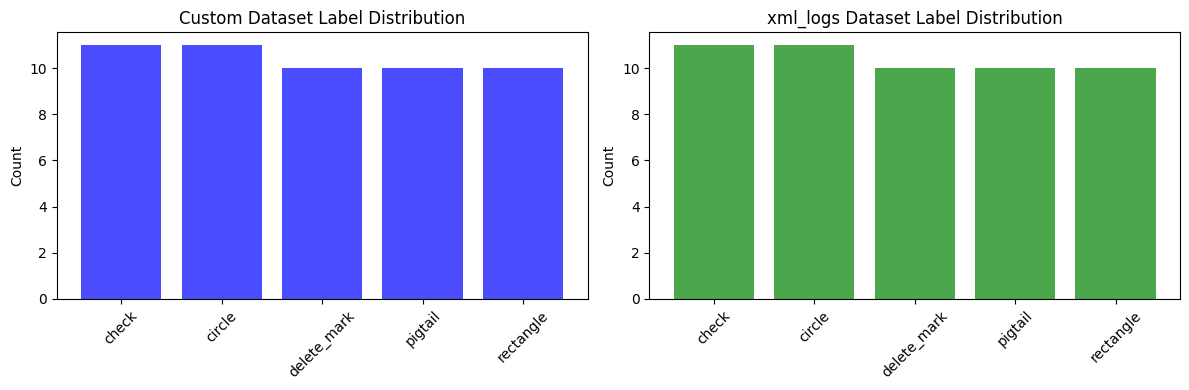

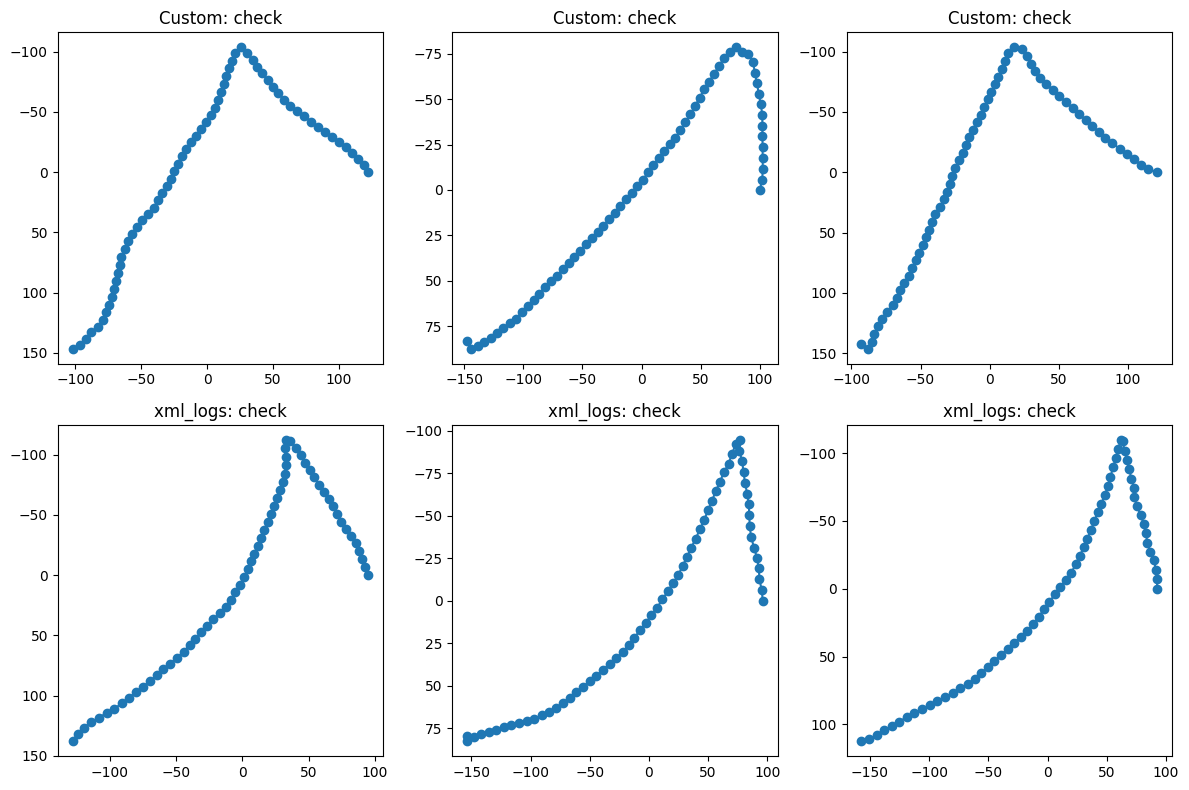

In [ ]:
# Truncate both datasets so that for each label, the number of samples is the minimum count for that label across both datasets


# Count occurrences of each label in both datasets
custom_counts = Counter(custom_labels)
xml_logs_counts = Counter(xml_logs_labels)

# Find common labels
common_labels = set(custom_counts.keys()) & set(xml_logs_counts.keys())

# For each label, keep only the minimum number of samples in both datasets
def filter_to_min_samples(data, labels, min_counts):
    filtered_data = []
    filtered_labels = []
    label_counter = defaultdict(int)
    for d, l in zip(data, labels):  # noqa: E741
        if l in min_counts and label_counter[l] < min_counts[l]:
            filtered_data.append(d)
            filtered_labels.append(l)
            label_counter[l] += 1
    return filtered_data, filtered_labels

min_counts = {label: min(custom_counts[label], xml_logs_counts[label]) for label in common_labels}

custom_data_sym, custom_labels_sym = filter_to_min_samples(custom_data, custom_labels, min_counts)
xml_logs_data_sym, xml_logs_labels_sym = filter_to_min_samples(xml_logs_data, xml_logs_labels, min_counts)

print(f"Symmetrical datasets created with {sum(min_counts.values())} samples per dataset.")
# Plot label distributions
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

custom_label_counts = Counter(custom_labels_sym)
xml_logs_label_counts = Counter(xml_logs_labels_sym)

axs[0].bar(custom_label_counts.keys(), custom_label_counts.values(), color='blue', alpha=0.7)
axs[0].set_title('Custom Dataset Label Distribution')
axs[0].set_ylabel('Count')
axs[0].set_xticks(range(len(custom_label_counts)))
axs[0].set_xticklabels(list(custom_label_counts.keys()), rotation=45)

axs[1].bar(xml_logs_label_counts.keys(), xml_logs_label_counts.values(), color='green', alpha=0.7)
axs[1].set_title('xml_logs Dataset Label Distribution')
axs[1].set_ylabel('Count')
axs[1].set_xticks(range(len(xml_logs_label_counts)))
axs[1].set_xticklabels(list(xml_logs_label_counts.keys()), rotation=45)

plt.tight_layout()
plt.show()

# Show a few gesture samples from both datasets
fig, axs = plt.subplots(2, 3, figsize=(12, 8))
for i in range(3):
    axs[0, i].plot(np.array(custom_data_sym[i])[:, 0], np.array(custom_data_sym[i])[:, 1], marker='o')
    axs[0, i].set_title(f'Custom: {custom_labels_sym[i]}')
    axs[0, i].invert_yaxis()
    axs[1, i].plot(np.array(xml_logs_data_sym[i])[:, 0], np.array(xml_logs_data_sym[i])[:, 1], marker='o')
    axs[1, i].set_title(f'xml_logs: {xml_logs_labels_sym[i]}')
    axs[1, i].invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Load Full xml_logs Dataset
Load the entire xml_logs dataset (not truncated) for LSTM training.

In [4]:
# Reload the entire xml_logs dataset for LSTM training
xml_logs_files_full = find_xml_files(xml_logs_dir)
xml_logs_data_full = []
xml_logs_labels_full = []
for file in xml_logs_files_full:
    points, path = parse_gesture_xml(file)
    label = os.path.basename(file).split('.')[0][:-2]
    xml_logs_data_full.append(points)
    xml_logs_labels_full.append(label)

print(f"Loaded {len(xml_logs_data_full)} samples from full xml_logs dataset.")

Loaded 5280 samples from full xml_logs dataset.


## 5. Preprocess Data for LSTM Training
Normalize and reshape the gesture data as required for LSTM input. Encode labels and split the data into training and validation sets.

In [5]:
# max sequence length
max_len = 64

def normalize_points(points, target_len=64):
    # Resample to fixed number of points
    points = np.array(points)
    if len(points) == 0:
        return np.zeros((target_len, 2))
    if len(points) == target_len:
        return points
    # Linear interpolation for resampling
    idxs = np.linspace(0, len(points) - 1, target_len)
    resampled = np.vstack([
        np.interp(idxs, np.arange(len(points)), points[:, 0]),
        np.interp(idxs, np.arange(len(points)), points[:, 1])
    ]).T
    return resampled

X = np.array(xml_logs_data)
le = LabelEncoder()
y = le.fit_transform(xml_logs_labels)
y_cat = to_categorical(y)

# Split into train/val
X_train, X_val, y_train, y_val = train_test_split(X, y_cat, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

X_train shape: (4224, 64, 2), y_train shape: (4224, 16)


## 7. Build and Train LSTM Model
Define and train an LSTM model using TensorFlow/Keras on the preprocessed xml_logs dataset.

In [6]:
# Define LSTM model
num_classes = y_cat.shape[1]
num_lstm_layers = 1
def get_layer_set(return_sequences=False, num_layers=1):
    if num_layers <= 0:
        return []
    return [
        LSTM(32, return_sequences=(num_layers > 1 or return_sequences)),
        Dropout(0.3),
        *get_layer_set(return_sequences=return_sequences, num_layers=num_layers - 1)
    ]


model = Sequential([
    Input(shape=(max_len, 2)),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    *get_layer_set(return_sequences=False, num_layers=num_lstm_layers),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Train the model
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping]
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,096 (117.56 KB)

 Trainable params: 30,096 (117.56 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.4374 - loss: 2.0242 - val_accuracy: 0.9091 - val_loss: 0.5273
Epoch 2/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8987 - loss: 0.5292 - val_accuracy: 0.9564 - val_loss: 0.2412
Epoch 3/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9402 - loss: 0.2747 - val_accuracy: 0.9536 - val_loss: 0.1887
Epoch 4/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9506 - loss: 0.2252 - val_accuracy: 0.9697 - val_loss: 0.1198
Epoch 5/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9681 - loss: 0.1548 - val_accuracy: 0.9602 - val_loss: 0.1289
Epoch 6/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9677 - loss: 0.1439 - val_accuracy: 0.9280 - val_loss: 0.2521
Epoch 7/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9723 - loss: 0.1294 - val_accuracy: 0.9830 - val_loss: 0.0708
Epoch 8/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9809 - loss: 0.0872 - val_accu

In [ ]:
# Evaluate $1 recognizer on truncated custom and xml_logs datasets

def eval_recognizer_on_dataset(data, labels, recognizer, max_len):
    correct = 0
    total = len(data)
    inference_times = []
    for i, (points, label) in enumerate(zip(data, labels)):
        start_time = time.perf_counter()
        pred_label, *_ = recognizer.recognize(points)
        inference_times.append(time.perf_counter() - start_time)
        if pred_label == label:
            correct += 1
    acc = correct / total
    mean_inference_time = sum(inference_times) / total
    return acc, mean_inference_time

# Train recognizer on custom_data
recognizer_custom = Recognizer(num_points=max_len, load_dataset=False)
for points, label in zip(custom_data_sym, custom_labels_sym):
    recognizer_custom.add_custom_template(label, points, times=None)
    
# Train recognizer on xml_logs_data
recognizer_xml = Recognizer(num_points=max_len, load_dataset=False)
for points, label in zip(xml_logs_data_sym, xml_logs_labels_sym):
    recognizer_xml.add_custom_template(label, points, times=None)

# Evaluate on custom_data
acc_custom, time_custom = eval_recognizer_on_dataset(custom_data_sym, custom_labels_sym, recognizer_custom, max_len)
print(f"$1 Recognizer on custom_data: Accuracy={acc_custom:.4f}, Mean Inference Time={time_custom:.6f} s")

# Evaluate on xml_logs_data
acc_xml, time_xml = eval_recognizer_on_dataset(xml_logs_data_sym, xml_logs_labels_sym, recognizer_xml, max_len)
print(f"$1 Recognizer on xml_logs_data: Accuracy={acc_xml:.4f}, Mean Inference Time={time_xml:.6f} s")

# Store results
results_dollar_custom = {'acc': acc_custom, 'mean_inference_time': time_custom}
results_dollar_xml = {'acc': acc_xml, 'mean_inference_time': time_xml}

$1 Recognizer on custom_data: Accuracy=1.0000, Mean Inference Time=0.001741 s
$1 Recognizer on xml_logs_data: Accuracy=1.0000, Mean Inference Time=0.002038 s


In [ ]:
# Evaluate LSTM on truncated custom and xml_logs datasets

def prepare_lstm_data(data, labels, max_len, le):
    X = np.array([normalize_points(p, max_len) for p in data])
    y = le.transform(labels)
    y_cat = to_categorical(y, num_classes=len(le.classes_))
    return X, y, y_cat

# Prepare data
X_custom, y_custom_enc, y_custom_cat = prepare_lstm_data(custom_data_sym, custom_labels_sym, max_len, le)
X_xml, y_xml_enc, y_xml_cat = prepare_lstm_data(xml_logs_data_sym, xml_logs_labels_sym, max_len, le)

def eval_lstm_on_dataset(X, y, le, model):
    correct = 0
    total = len(X)
    inference_times = []
    for i, (points, true_idx) in enumerate(zip(X, y)):
        start_time = time.perf_counter()
        pred_probs = model.predict(points[np.newaxis, ...], verbose=0)
        pred_label = np.argmax(pred_probs)
        inference_times.append(time.perf_counter() - start_time)
        if pred_label == true_idx:
            correct += 1
    acc = correct / total
    mean_inference_time = sum(inference_times) / total
    return acc, mean_inference_time

# Evaluate on custom_data
lstm_acc_custom, lstm_time_custom = eval_lstm_on_dataset(X_custom, y_custom_enc, le, model)
print(f"LSTM on custom_data: Accuracy={lstm_acc_custom:.4f}, Mean Inference Time={lstm_time_custom:.6f} s")

# Evaluate on xml_logs_data
lstm_acc_xml, lstm_time_xml = eval_lstm_on_dataset(X_xml, y_xml_enc, le, model)
print(f"LSTM on xml_logs_data: Accuracy={lstm_acc_xml:.4f}, Mean Inference Time={lstm_time_xml:.6f} s")

# Store results
results_lstm_custom = {'acc': lstm_acc_custom, 'mean_inference_time': lstm_time_custom}
results_lstm_xml = {'acc': lstm_acc_xml, 'mean_inference_time': lstm_time_xml}

LSTM on custom_data: Accuracy=0.7500, Mean Inference Time=0.057186 s
LSTM on xml_logs_data: Accuracy=1.0000, Mean Inference Time=0.054664 s


## 8. Compare Performance

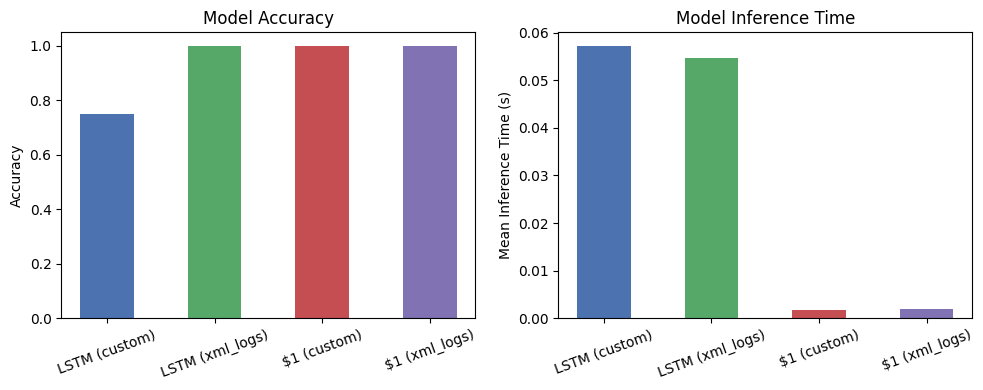

In [ ]:
# Prepare data for plotting
model_names = ["LSTM (custom)", "LSTM (xml_logs)", "$1 (custom)", "$1 (xml_logs)"]
acc = [
    results_lstm_custom['acc'],
    results_lstm_xml['acc'],
    results_dollar_custom['acc'],
    results_dollar_xml['acc']
]
mean_inference_time = [
    results_lstm_custom['mean_inference_time'],
    results_lstm_xml['mean_inference_time'],
    results_dollar_custom['mean_inference_time'],
    results_dollar_xml['mean_inference_time']
]

x = np.arange(len(model_names))
width = 0.5

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Accuracy plot
axs[0].bar(x, acc, width, color=['#4C72B0', '#55A868', '#C44E52', '#8172B3'])
axs[0].set_xticks(x)
axs[0].set_xticklabels(model_names, rotation=20)
axs[0].set_ylabel('Accuracy')
axs[0].set_title('Model Accuracy')

# Inference time plot
axs[1].bar(x, mean_inference_time, width, color=['#4C72B0', '#55A868', '#C44E52', '#8172B3'])
axs[1].set_xticks(x)
axs[1].set_xticklabels(model_names, rotation=20)
axs[1].set_ylabel('Mean Inference Time (s)')
axs[1].set_title('Model Inference Time')

plt.tight_layout()
plt.show()